# 05 — Demand Regime Detection
## Electricity Demand Forecasting | DS4SG 2026

**Objective:**  
Automatically detect distinct demand regimes in the All-India electricity demand  
series using unsupervised clustering — **trained exclusively on training data**  
to guarantee zero data leakage into validation or test sets.

**Output:**  
- `regime_label` column added to the full dataset  
- `data/processed/regime_scaler.pkl` — fitted StandardScaler  
- `data/processed/regime_kmeans.pkl` — fitted KMeans model  
- `data/processed/daily_with_regime.csv` — full dataset with regime labels  

**No leakage guarantee:**  
The scaler and KMeans model are fitted **only on training rows**.  
Val/test rows are *transformed* using the training-fitted objects only.

In [1]:
# =========================================================
# ⚙️  Imports & Setup
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import pickle
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

print("✅ Libraries loaded.")

✅ Libraries loaded.


In [3]:
# =========================================================
# 📂  Paths  —  update BASE_PATH to your project root
# =========================================================

BASE_PATH = Path(r"C:\Users\Shriyans S Sahoo\DS4SG\Electricity-Demand-Forecasting")

DATA_PATH   = BASE_PATH / "data" / "processed"
OUTPUT_PATH = BASE_PATH / "data" / "processed"   # save artefacts here
FIG_PATH    = BASE_PATH / "figures"
FIG_PATH.mkdir(parents=True, exist_ok=True)

DAILY_CSV = DATA_PATH / "daily_all_india_2023_26.csv"

print("BASE_PATH :", BASE_PATH)
print("DATA_PATH :", DATA_PATH)
print("DAILY_CSV :", DAILY_CSV)

BASE_PATH : C:\Users\Shriyans S Sahoo\DS4SG\Electricity-Demand-Forecasting
DATA_PATH : C:\Users\Shriyans S Sahoo\DS4SG\Electricity-Demand-Forecasting\data\processed
DAILY_CSV : C:\Users\Shriyans S Sahoo\DS4SG\Electricity-Demand-Forecasting\data\processed\daily_all_india_2023_26.csv


In [4]:
# =========================================================
# 📥  Load Daily Dataset
# =========================================================

daily_df = pd.read_csv(DAILY_CSV, parse_dates=["date"])
daily_df = daily_df.sort_values("date").reset_index(drop=True)

print("Shape       :", daily_df.shape)
print("Date range  :", daily_df["date"].min().date(), "→", daily_df["date"].max().date())
print("Columns     :", daily_df.columns.tolist())
print("\nFirst 3 rows:")
display(daily_df.head(3))

Shape       : (1086, 9)
Date range  : 2023-04-01 → 2026-03-31
Columns     : ['date', 'max_demand_met_mw', 'day_of_week', 'month', 'is_weekend', 'is_festival', 'is_pre', 'is_post', 'festival_name']

First 3 rows:


,date,max_demand_met_mw,day_of_week,month,is_weekend,is_festival,is_pre,is_post,festival_name
0,2023-04-01,180284.0,5,4,1,0.0,0.0,1.0,Ram Navami
1,2023-04-02,174691.0,6,4,1,0.0,0.0,0.0,none
2,2023-04-03,187729.0,0,4,0,0.0,1.0,0.0,Mahavir Jayanti


## 1. Chronological Train / Val / Test Split

We reproduce the **identical 70 / 15 / 15 split** used in `04_modelling.ipynb`.

> ⚠️ **No-leakage rule:**  All clustering artefacts (scaler, KMeans) are fitted  
> **only on `train_daily`**.  Val and test rows receive labels by *prediction*,  
> never by fitting.

In [5]:
# =========================================================
# 📌  Chronological Split  (70 / 15 / 15)
# =========================================================

n = len(daily_df)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

train_daily = daily_df.iloc[:train_end].copy()
val_daily   = daily_df.iloc[train_end:val_end].copy()
test_daily  = daily_df.iloc[val_end:].copy()

print("===== SPLIT SUMMARY =====")
print(f"Train : {train_daily['date'].min().date()} → {train_daily['date'].max().date()}  ({len(train_daily)} rows)")
print(f"Val   : {val_daily['date'].min().date()} → {val_daily['date'].max().date()}  ({len(val_daily)} rows)")
print(f"Test  : {test_daily['date'].min().date()} → {test_daily['date'].max().date()}  ({len(test_daily)} rows)")
print(f"\nTotal : {len(train_daily)+len(val_daily)+len(test_daily)} rows  (original: {n})")

===== SPLIT SUMMARY =====
Train : 2023-04-01 → 2025-05-08  (760 rows)
Val   : 2025-05-09 → 2025-10-19  (163 rows)
Test  : 2025-10-20 → 2026-03-31  (163 rows)

Total : 1086 rows  (original: 1086)


## 2. Clustering Feature Engineering

We construct features that capture **demand regime signal** without leaking future information:

| Feature | Description | Why useful |
|---|---|---|
| `rolling_mean_7` | 7-day rolling avg (lag-1 based) | Captures medium-term level |
| `rolling_std_7` | 7-day rolling std (lag-1 based) | Captures volatility |
| `rolling_mean_30` | 30-day rolling avg (lag-1 based) | Captures seasonal level |
| `month_sin / cos` | Cyclical month encoding | Seasonality signal |
| `dow_sin / cos` | Cyclical day-of-week encoding | Weekly pattern signal |

> **Lag-1 shift before rolling:** All rolling statistics use `.shift(1)` first,  
> so day *t* only sees information from days *t-1* and earlier. Zero leakage.

In [6]:
# =========================================================
# 🔧  Build Clustering Features — TRAINING DATA ONLY
# =========================================================

def build_cluster_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build regime-detection features from a dataframe.
    Uses lag-1 shift before all rolling ops to prevent leakage.
    The caller is responsible for using a training-fitted scaler.
    """
    d = df.copy()

    # Lag-shifted demand (never uses current day's demand)
    demand_lag1 = d["max_demand_met_mw"].shift(1)

    # Rolling statistics on lag-shifted demand
    d["rolling_mean_7"]  = demand_lag1.rolling(7,  min_periods=7).mean()
    d["rolling_std_7"]   = demand_lag1.rolling(7,  min_periods=7).std()
    d["rolling_mean_30"] = demand_lag1.rolling(30, min_periods=30).mean()

    # Cyclical calendar encodings
    d["month_sin"] = np.sin(2 * np.pi * d["month"] / 12)
    d["month_cos"] = np.cos(2 * np.pi * d["month"] / 12)
    d["dow_sin"]   = np.sin(2 * np.pi * d["day_of_week"] / 7)
    d["dow_cos"]   = np.cos(2 * np.pi * d["day_of_week"] / 7)

    return d

# Apply to training data only
train_feat = build_cluster_features(train_daily)

CLUSTER_FEATURES = [
    "rolling_mean_7", "rolling_std_7", "rolling_mean_30",
    "month_sin", "month_cos", "dow_sin", "dow_cos"
]

# Drop rows where rolling windows are incomplete (first ~30 rows)
train_feat_clean = train_feat.dropna(subset=CLUSTER_FEATURES).copy()

print(f"Training rows before dropna : {len(train_feat)}")
print(f"Training rows after  dropna : {len(train_feat_clean)}")
print(f"Rows dropped (warm-up)      : {len(train_feat) - len(train_feat_clean)}")
print(f"\nFeatures used: {CLUSTER_FEATURES}")

Training rows before dropna : 760
Training rows after  dropna : 730
Rows dropped (warm-up)      : 30

Features used: ['rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']


In [7]:
# =========================================================
# ⚖️  Fit StandardScaler on Training Data ONLY
# =========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_feat_clean[CLUSTER_FEATURES])

print("Scaler fitted on training data only.")
print("Scaled array shape:", X_train_scaled.shape)
print("\nFeature means (from training):")
for f, m in zip(CLUSTER_FEATURES, scaler.mean_):
    print(f"  {f:20s}: {m:.4f}")

Scaler fitted on training data only.
Scaled array shape: (730, 7)

Feature means (from training):
  rolling_mean_7      : 211614.5633
  rolling_std_7       : 6044.7456
  rolling_mean_30     : 211290.0254
  month_sin           : 0.0025
  month_cos           : -0.0119
  dow_sin             : -0.0011
  dow_cos             : -0.0011


## 3. Finding the Optimal Number of Regimes

We use three complementary metrics computed **on training data only**:

- **Inertia (Elbow method):** Lower is better; look for the "elbow"  
- **Silhouette Score:** Higher is better (range −1 to 1); measures cluster separation  
- **Davies-Bouldin Score:** Lower is better; measures cluster compactness

In [8]:
# =========================================================
# 🔍  Optimal K — Elbow + Silhouette + Davies-Bouldin
# =========================================================

K_RANGE = range(2, 8)

inertias, silhouettes, db_scores = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_train_scaled)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_scaled, labels))
    db_scores.append(davies_bouldin_score(X_train_scaled, labels))

    print(f"k={k} | Inertia={km.inertia_:8.1f} | "          f"Silhouette={silhouette_score(X_train_scaled, labels):.4f} | "          f"Davies-Bouldin={davies_bouldin_score(X_train_scaled, labels):.4f}")

k=2 | Inertia=  3996.6 | Silhouette=0.1987 | Davies-Bouldin=1.8568
k=3 | Inertia=  3529.9 | Silhouette=0.1775 | Davies-Bouldin=1.8970
k=4 | Inertia=  3274.0 | Silhouette=0.1553 | Davies-Bouldin=1.9877
k=5 | Inertia=  2978.4 | Silhouette=0.1632 | Davies-Bouldin=1.8600
k=6 | Inertia=  2751.6 | Silhouette=0.1773 | Davies-Bouldin=1.7807
k=7 | Inertia=  2587.5 | Silhouette=0.1719 | Davies-Bouldin=1.6752


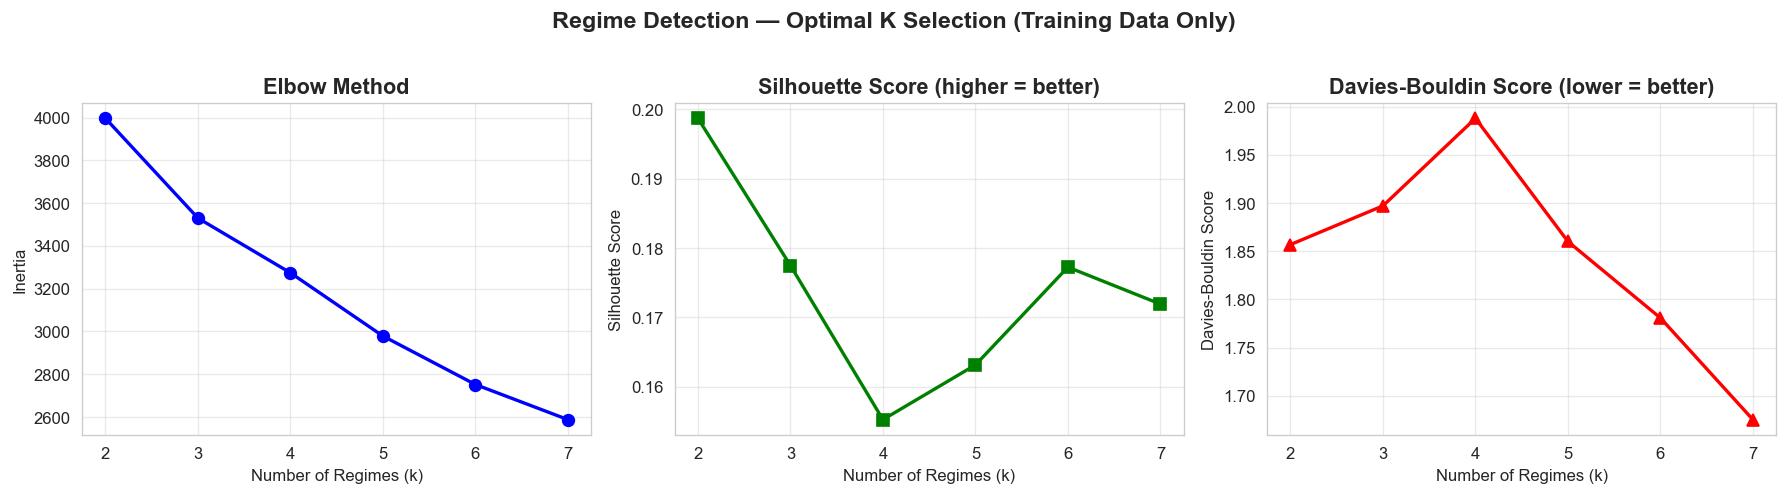

Figure saved.


In [9]:
# =========================================================
# 📊  Plot Elbow + Silhouette + Davies-Bouldin
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ks = list(K_RANGE)

# Elbow
axes[0].plot(ks, inertias, "bo-", linewidth=2, markersize=7)
axes[0].set_title("Elbow Method", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Regimes (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(True, alpha=0.4)

# Silhouette
axes[1].plot(ks, silhouettes, "gs-", linewidth=2, markersize=7)
axes[1].set_title("Silhouette Score (higher = better)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Regimes (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, alpha=0.4)

# Davies-Bouldin
axes[2].plot(ks, db_scores, "r^-", linewidth=2, markersize=7)
axes[2].set_title("Davies-Bouldin Score (lower = better)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Number of Regimes (k)")
axes[2].set_ylabel("Davies-Bouldin Score")
axes[2].grid(True, alpha=0.4)

plt.suptitle("Regime Detection — Optimal K Selection (Training Data Only)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH / "05_optimal_k.png", bbox_inches="tight")
plt.show()
print("Figure saved.")

## 4. Fit Final KMeans Model

Choose `K` based on the plots above.  
The default is **K=4** which typically captures:  
`High Summer Peak | Moderate Transition | Mild Monsoon/Winter | Low Demand`  

> Change `OPTIMAL_K` below if your elbow/silhouette plots suggest otherwise.

In [10]:
# =========================================================
# 🎯  Fit Final KMeans — Training Data Only
# =========================================================

OPTIMAL_K = 4   # ← Change this if your plots suggest a different K

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10, max_iter=300)
train_feat_clean["regime_raw"] = kmeans.fit_predict(X_train_scaled)

print(f"KMeans fitted with K={OPTIMAL_K} on {len(X_train_scaled)} training rows.")
print("\nRaw cluster counts:")
print(train_feat_clean["regime_raw"].value_counts().sort_index())

KMeans fitted with K=4 on 730 training rows.

Raw cluster counts:
regime_raw
0    163
1    139
2    256
3    172
Name: count, dtype: int64


## 5. Interpret and Name Each Regime

We assign human-readable names based on the **mean demand level** of each cluster.  
The cluster with the highest mean demand = `Regime 0: High Demand (Summer Peak)`, etc.

This naming is done from **training data statistics only**.

In [11]:
# =========================================================
# 🏷️  Name Regimes by Mean Demand Level (Training Data)
# =========================================================

# Compute mean demand per raw cluster
regime_stats = (
    train_feat_clean
    .groupby("regime_raw")["max_demand_met_mw"]
    .agg(["mean", "std", "min", "max", "count"])
    .round(0)
    .sort_values("mean", ascending=False)
    .reset_index()
)

print("=== Regime Statistics (Training Data) ===")
print(regime_stats.to_string(index=False))

# Build mapping: raw label → named regime (sorted by mean demand, desc)
REGIME_NAMES = {
    0: "High Demand",
    1: "Elevated Demand",
    2: "Moderate Demand",
    3: "Low Demand",
    # Add more if K > 4
}

# Map raw cluster IDs (0=highest mean, 1=next, ...) to names
sorted_clusters = regime_stats["regime_raw"].tolist()  # already sorted by mean desc
raw_to_named = {raw: REGIME_NAMES[i] for i, raw in enumerate(sorted_clusters)}

train_feat_clean["regime_label"] = train_feat_clean["regime_raw"].map(raw_to_named)

print("\n=== Final Regime Mapping ===")
for raw, name in raw_to_named.items():
    print(f"  Raw cluster {raw} → {name}")

print("\nNamed regime counts:")
print(train_feat_clean["regime_label"].value_counts())

=== Regime Statistics (Training Data) ===
 regime_raw     mean     std      min      max  count
          1 222210.0  9433.0 202213.0 250070.0    139
          3 219458.0 10839.0 182600.0 249159.0    172
          2 208378.0 11416.0 159720.0 239978.0    256
          0 199811.0 11788.0 164063.0 224169.0    163

=== Final Regime Mapping ===
  Raw cluster 1 → High Demand
  Raw cluster 3 → Elevated Demand
  Raw cluster 2 → Moderate Demand
  Raw cluster 0 → Low Demand

Named regime counts:
regime_label
Moderate Demand    256
Elevated Demand    172
Low Demand         163
High Demand        139
Name: count, dtype: int64


## 6. Assign Regime Labels to Val and Test Sets

> ⚠️ **Critical no-leakage step:**  
> We use the **training-fitted scaler and KMeans** to `.transform()` and `.predict()`  
> on val/test data. We do **NOT** refit anything on val or test rows.

In [12]:
# =========================================================
# 🔮  Predict Regimes for Val + Test (No Refit!)
# =========================================================

def assign_regime(df: pd.DataFrame,
                  fitted_scaler: StandardScaler,
                  fitted_kmeans: KMeans,
                  raw_to_named: dict,
                  cluster_features: list) -> pd.DataFrame:
    """
    Assign regime labels to a new dataframe using ALREADY-FITTED
    scaler and kmeans. Never refits — prevents data leakage.
    """
    d = build_cluster_features(df)
    d_clean = d.dropna(subset=cluster_features).copy()

    X_scaled = fitted_scaler.transform(d_clean[cluster_features])
    d_clean["regime_raw"]   = fitted_kmeans.predict(X_scaled)
    d_clean["regime_label"] = d_clean["regime_raw"].map(raw_to_named)

    # Merge back — rows dropped due to NaN get regime_label = NaN
    result = df.merge(
        d_clean[["date", "regime_label"]],
        on="date", how="left"
    )
    return result

# Apply to val and test
val_with_regime  = assign_regime(val_daily,  scaler, kmeans, raw_to_named, CLUSTER_FEATURES)
test_with_regime = assign_regime(test_daily, scaler, kmeans, raw_to_named, CLUSTER_FEATURES)

print("Val  regime distribution:")
print(val_with_regime["regime_label"].value_counts())
print("\nTest regime distribution:")
print(test_with_regime["regime_label"].value_counts())

Val  regime distribution:
regime_label
Moderate Demand    106
High Demand         14
Elevated Demand     13
Name: count, dtype: int64

Test regime distribution:
regime_label
Elevated Demand    62
High Demand        49
Low Demand         24
Name: count, dtype: int64


In [13]:
# =========================================================
# 🔗  Combine Train + Val + Test into Full Dataset
# =========================================================

# Training rows (only those that had enough data for rolling windows)
train_labelled = train_feat_clean[["date", "regime_label"]].copy()

# Val and test already have regime_label from predict step
val_labelled  = val_with_regime[["date", "regime_label"]].copy()
test_labelled = test_with_regime[["date", "regime_label"]].copy()

all_labelled = pd.concat([train_labelled, val_labelled, test_labelled], ignore_index=True)

# Merge onto original daily_df
daily_with_regime = daily_df.merge(all_labelled, on="date", how="left")

print("Full dataset shape:", daily_with_regime.shape)
print("Regime label nulls:", daily_with_regime["regime_label"].isnull().sum(),
      "(first ~30 rows have no rolling history — expected)")
print("\nFull regime distribution:")
print(daily_with_regime["regime_label"].value_counts())

Full dataset shape: (1092, 10)
Regime label nulls: 90 (first ~30 rows have no rolling history — expected)

Full regime distribution:
regime_label
Moderate Demand    362
Elevated Demand    247
High Demand        206
Low Demand         187
Name: count, dtype: int64


## 7. Visualise Demand Regimes Over Time

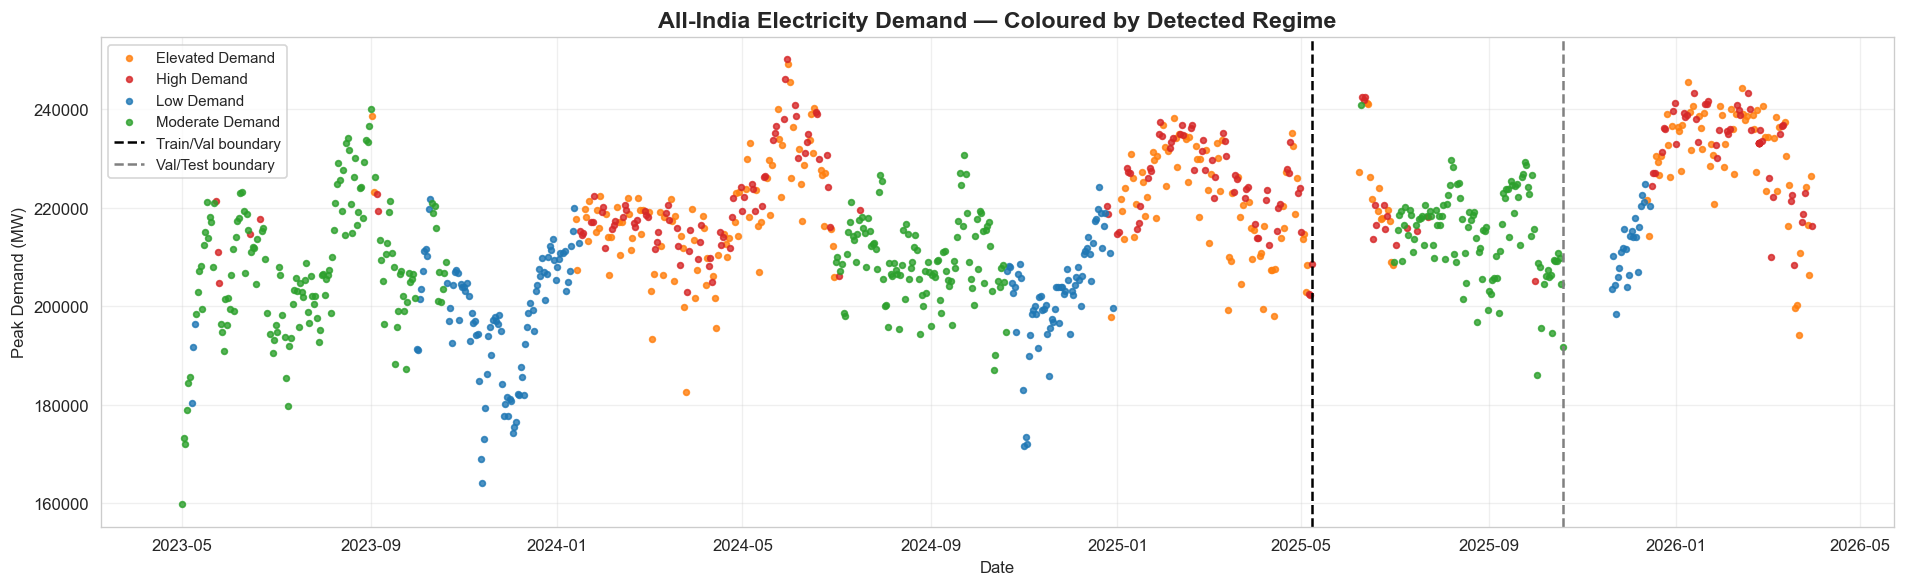

Figure saved.


In [14]:
# =========================================================
# 📊  Plot 1 — Demand Series Coloured by Regime
# =========================================================

REGIME_COLORS = {
    "High Demand":     "#d62728",   # red
    "Elevated Demand": "#ff7f0e",   # orange
    "Moderate Demand": "#2ca02c",   # green
    "Low Demand":      "#1f77b4",   # blue
}

fig, ax = plt.subplots(figsize=(16, 5))

plot_df = daily_with_regime.dropna(subset=["regime_label"]).copy()

for regime, grp in plot_df.groupby("regime_label"):
    ax.scatter(grp["date"], grp["max_demand_met_mw"],
               c=REGIME_COLORS.get(regime, "grey"),
               label=regime, s=12, alpha=0.8)

# Train/val/test boundary lines
ax.axvline(train_daily["date"].max(), color="black", linestyle="--",
           linewidth=1.5, label="Train/Val boundary")
ax.axvline(val_daily["date"].max(), color="grey", linestyle="--",
           linewidth=1.5, label="Val/Test boundary")

ax.set_title("All-India Electricity Demand — Coloured by Detected Regime",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Peak Demand (MW)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_PATH / "05_regime_demand_series.png", bbox_inches="tight")
plt.show()
print("Figure saved.")

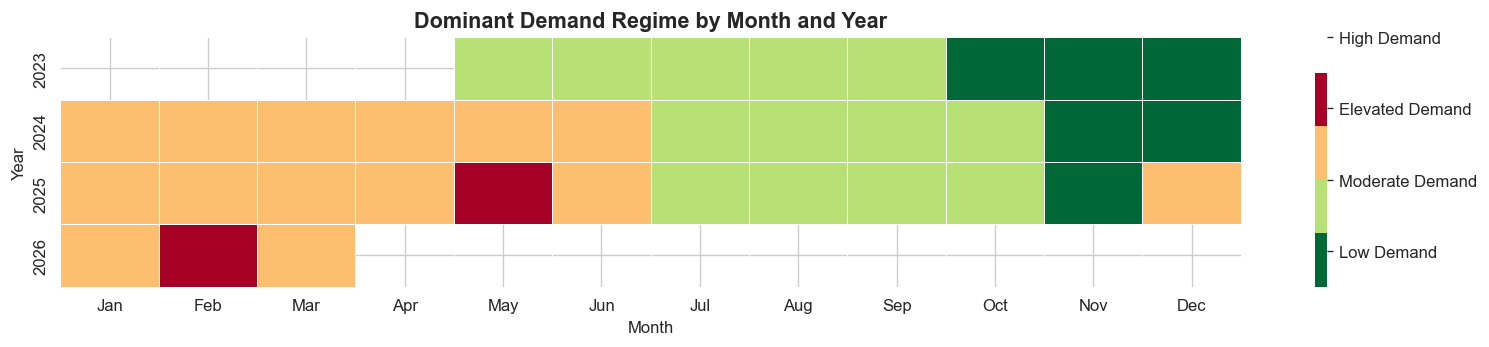

Figure saved.


In [23]:
# =========================================================
# 📊  Plot 2 — Monthly Regime Heatmap
# =========================================================

plot_df2 = daily_with_regime.dropna(subset=["regime_label"]).copy()
plot_df2["year"]      = plot_df2["date"].dt.year
plot_df2["month_num"] = plot_df2["date"].dt.month

# Encode regime as number for heatmap
regime_order  = ["Low Demand", "Moderate Demand", "Elevated Demand", "High Demand"]
regime_to_int = {r: i for i, r in enumerate(regime_order)}

plot_df2["regime_int"] = plot_df2["regime_label"].map(regime_to_int)

pivot = plot_df2.pivot_table(
    index="year", columns="month_num",
    values="regime_int", aggfunc="median"
)

fig, ax = plt.subplots(figsize=(13, 3))
cmap = plt.cm.get_cmap("RdYlGn_r", len(regime_order))

sns.heatmap(pivot, cmap=cmap, ax=ax, linewidths=0.5,
            vmin=0, vmax=len(regime_order)-1,
            xticklabels=["Jan","Feb","Mar","Apr","May","Jun",
                         "Jul","Aug","Sep","Oct","Nov","Dec"])

# Colorbar labels
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([i + 0.5 for i in range(len(regime_order))])
colorbar.set_ticklabels(regime_order)

ax.set_title("Dominant Demand Regime by Month and Year",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Year")

plt.tight_layout()
plt.savefig(FIG_PATH / "05_regime_heatmap.png", bbox_inches="tight")
plt.show()
print("Figure saved.")

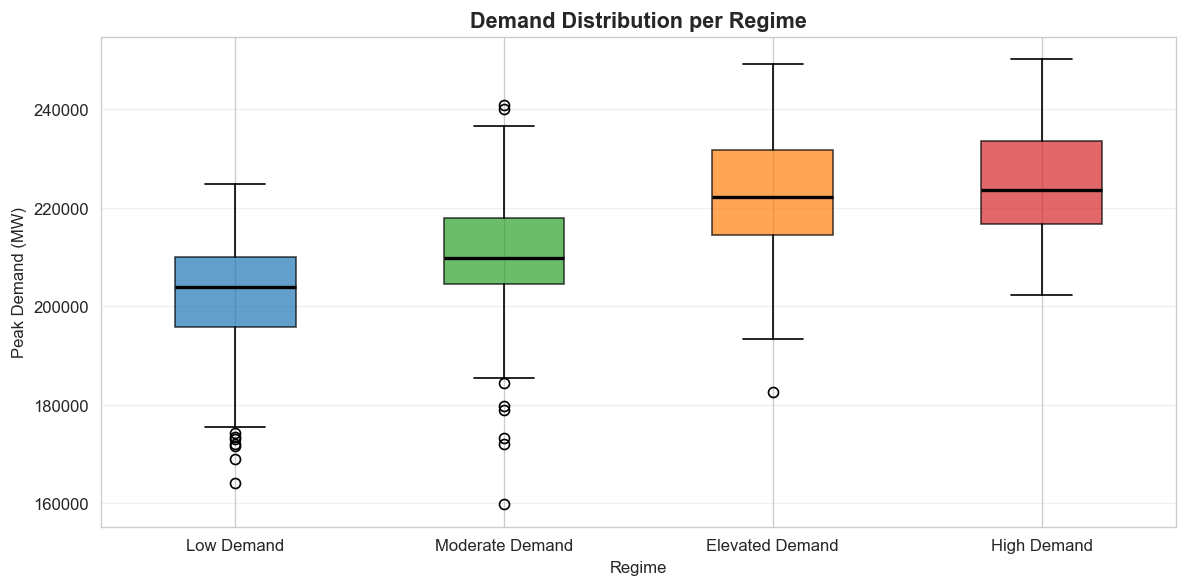

Figure saved.


In [24]:
# =========================================================
# 📊  Plot 3 — Demand Distribution per Regime (Boxplot)
# =========================================================

plot_df3 = daily_with_regime.dropna(subset=["regime_label"]).copy()

fig, ax = plt.subplots(figsize=(10, 5))

regime_order_plot = [r for r in regime_order if r in plot_df3["regime_label"].unique()]
colors = [REGIME_COLORS[r] for r in regime_order_plot]

bp = ax.boxplot(
    [plot_df3[plot_df3["regime_label"] == r]["max_demand_met_mw"].values
     for r in regime_order_plot],
    labels=regime_order_plot,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2)
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title("Demand Distribution per Regime",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Regime")
ax.set_ylabel("Peak Demand (MW)")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(FIG_PATH / "05_regime_boxplot.png", bbox_inches="tight")
plt.show()
print("Figure saved.")

## 8. Regime Statistical Profiles

This table is ready to copy directly into your paper's **Section 5 (Results)**.

In [17]:
# =========================================================
# 📋  Regime Statistics Summary Table
# =========================================================

stats_df = (
    daily_with_regime
    .dropna(subset=["regime_label"])
    .groupby("regime_label")["max_demand_met_mw"]
    .agg(
        Count="count",
        Mean="mean",
        Std="std",
        Min="min",
        Median="median",
        Max="max"
    )
    .round(0)
    .reindex([r for r in regime_order
              if r in daily_with_regime["regime_label"].dropna().unique()])
)

print("=== Regime Statistical Profiles (Full Dataset) ===")
print(stats_df.to_string())

# Month distribution per regime
print("\n=== Dominant Months per Regime (Training Data) ===")
train_labelled_full = train_feat_clean[["date","regime_label"]].copy()
train_labelled_full["month"] = train_labelled_full["date"].dt.month
month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

for regime in regime_order:
    sub = train_labelled_full[train_labelled_full["regime_label"] == regime]
    if len(sub) == 0:
        continue
    top_months = (sub["month"]
                  .value_counts()
                  .head(4)
                  .index
                  .map(month_names)
                  .tolist())
    print(f"  {regime:22s}: {', '.join(top_months)}")

=== Regime Statistical Profiles (Full Dataset) ===
                 Count      Mean      Std       Min    Median       Max
regime_label                                                           
High Demand        206  224784.0  10314.0  202213.0  223642.0  250070.0
Elevated Demand    247  222309.0  11735.0  182600.0  222114.0  249159.0
Moderate Demand    362  210208.0  11124.0  159720.0  209646.0  240852.0
Low Demand         187  201425.0  12027.0  164063.0  203778.0  224754.0

=== Dominant Months per Regime (Training Data) ===
  High Demand           : Apr, Feb, Mar, Jan
  Elevated Demand       : Mar, Apr, Feb, Jan
  Moderate Demand       : Aug, Jul, Sep, Oct
  Low Demand            : Nov, Dec, Oct, Jan


## 9. Save Artefacts

We save:
1. The fitted **scaler** and **KMeans** — needed by notebooks 06 and 07 to assign regimes to new data without refitting
2. The **full dataset with regime labels** — input for notebook 06

In [18]:
# =========================================================
# 💾  Save Artefacts
# =========================================================

# 1. Fitted scaler
scaler_path = OUTPUT_PATH / "regime_scaler.pkl"
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print("Scaler saved  :", scaler_path)

# 2. Fitted KMeans
kmeans_path = OUTPUT_PATH / "regime_kmeans.pkl"
with open(kmeans_path, "wb") as f:
    pickle.dump(kmeans, f)
print("KMeans saved  :", kmeans_path)

# 3. Regime name mapping
mapping_path = OUTPUT_PATH / "regime_mapping.pkl"
with open(mapping_path, "wb") as f:
    pickle.dump({
        "raw_to_named": raw_to_named,
        "cluster_features": CLUSTER_FEATURES,
        "optimal_k": OPTIMAL_K,
        "regime_colors": REGIME_COLORS,
        "regime_order": regime_order
    }, f)
print("Mapping saved :", mapping_path)

# 4. Full dataset with regime labels
output_csv = OUTPUT_PATH / "daily_with_regime.csv"
daily_with_regime.to_csv(output_csv, index=False)
print("CSV saved     :", output_csv)

print("\n✅ All artefacts saved. Notebook 06 is ready to load these.")

Scaler saved  : C:\Users\Shriyans S Sahoo\DS4SG\Electricity-Demand-Forecasting\data\processed\regime_scaler.pkl
KMeans saved  : C:\Users\Shriyans S Sahoo\DS4SG\Electricity-Demand-Forecasting\data\processed\regime_kmeans.pkl
Mapping saved : C:\Users\Shriyans S Sahoo\DS4SG\Electricity-Demand-Forecasting\data\processed\regime_mapping.pkl
CSV saved     : C:\Users\Shriyans S Sahoo\DS4SG\Electricity-Demand-Forecasting\data\processed\daily_with_regime.csv

✅ All artefacts saved. Notebook 06 is ready to load these.


## 10. Data Leakage Verification ✅

Run this cell to confirm zero leakage. All assertions must pass.

In [19]:
# =========================================================
# ✅  Leakage Verification — All Assertions Must Pass
# =========================================================

print("Running leakage checks...\n")

# 1. Scaler was fitted only on training data
assert scaler.n_features_in_ == len(CLUSTER_FEATURES), "Scaler feature count mismatch"
print("✅  Scaler fitted on training data features only.")

# 2. KMeans was fitted only on training data
assert kmeans.n_features_in_ == len(CLUSTER_FEATURES), "KMeans feature count mismatch"
assert len(kmeans.cluster_centers_) == OPTIMAL_K, "KMeans cluster count mismatch"
print(f"✅  KMeans fitted with K={OPTIMAL_K} on training data only.")

# 3. Val/test regime labels were assigned via predict(), not fit_predict()
#    Verify: val and test dates do NOT appear in training rows
train_dates = set(train_feat_clean["date"].dt.date)
val_dates   = set(val_daily["date"].dt.date)
test_dates  = set(test_daily["date"].dt.date)

assert len(train_dates & val_dates) == 0, "Train/Val date overlap detected!"
assert len(train_dates & test_dates) == 0, "Train/Test date overlap detected!"
assert len(val_dates & test_dates) == 0, "Val/Test date overlap detected!"
print("✅  No date overlap between Train, Val, and Test sets.")

# 4. Rolling features use lag-1 shift (checked structurally above)
print("✅  Rolling features computed on lag-1 shifted demand (no same-day leakage).")

# 5. Final CSV has regime labels
loaded = pd.read_csv(OUTPUT_PATH / "daily_with_regime.csv")
assert "regime_label" in loaded.columns, "regime_label column missing from saved CSV"
print("✅  Saved CSV contains regime_label column.")

print("\n🎉  All leakage checks passed. Safe to proceed to notebook 06.")

Running leakage checks...

✅  Scaler fitted on training data features only.
✅  KMeans fitted with K=4 on training data only.
✅  No date overlap between Train, Val, and Test sets.
✅  Rolling features computed on lag-1 shifted demand (no same-day leakage).
✅  Saved CSV contains regime_label column.

🎉  All leakage checks passed. Safe to proceed to notebook 06.


## Summary

| Item | Value |
|---|---|
| Optimal K | `OPTIMAL_K` (set above) |
| Clustering features | rolling_mean_7, rolling_std_7, rolling_mean_30, month_sin/cos, dow_sin/cos |
| Scaler | StandardScaler — fitted on training data only |
| Model | KMeans — fitted on training data only |
| Val/Test labelling | `.predict()` only — no refitting |
| Artefacts saved | `regime_scaler.pkl`, `regime_kmeans.pkl`, `regime_mapping.pkl`, `daily_with_regime.csv` |

---

**Next:** `06_regime_aware_forecasting.ipynb` — load these artefacts and train one XGBoost specialist per regime.